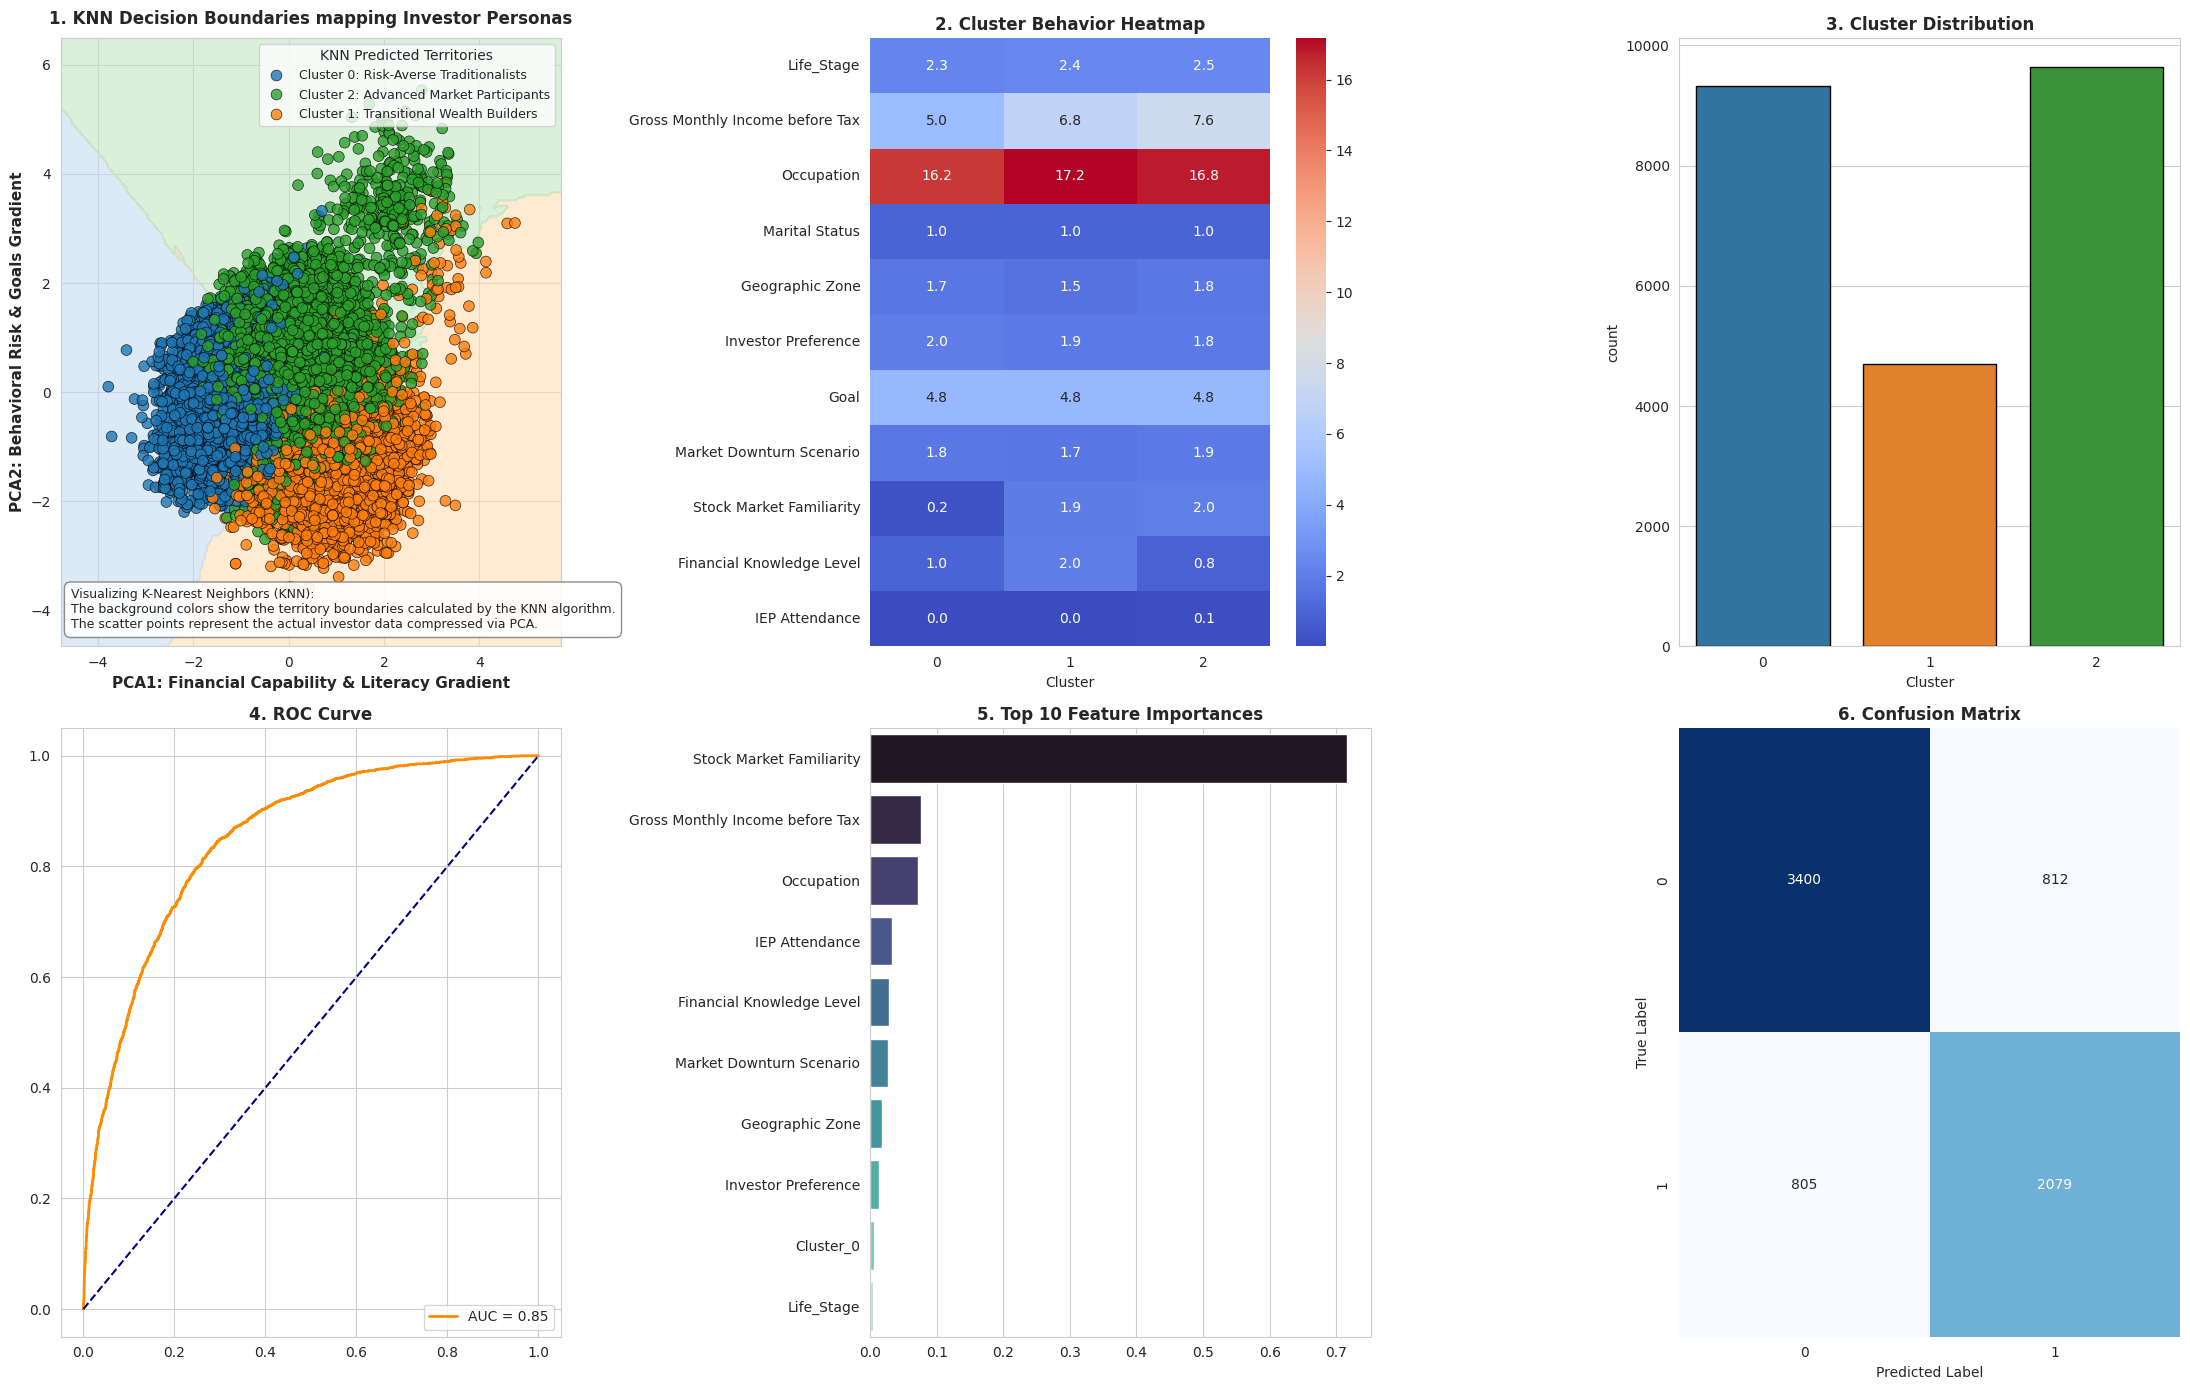

HTML(value="<h2 style='color:#2a75d3;'>Investment Predictor Engine</h2>")

Dropdown(description='Asset Class:', layout=Layout(width='400px'), options={'Futures & Options (F&O)': 'ADI_Da…

Button(button_style='success', description='Predict Adoption Probability', layout=Layout(width='300px'), style…

Output()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')

file_path = "/content/SEBI Investor Survey Data 2025.XLSX"
try:
    df_raw = pd.read_excel(file_path)
except FileNotFoundError:
    print(f"Could not find '{file_path}'. Please check the path.")
    raise

product_cols = [c for c in df_raw.columns if 'ADI_Dashboard' in c]
product_mapping = {col: str(df_raw.iloc[0][col]).split(':')[0].strip() for col in product_cols}
df_clean = df_raw.drop(0).reset_index(drop=True)

demographics = ['Life_Stage', 'Gross Monthly Income before Tax', 'Occupation', 'Marital Status', 'Geographic Zone']
inv_behavior = ['Investor Preference', 'Goal', 'Market Downturn Scenario']
literacy_media = ['Stock Market Familiarity', 'Financial Knowledge Level', 'IEP Attendance']
target_col = 'Investor Status'
features = demographics + inv_behavior + literacy_media

X_full = df_clean[features].copy()

for col in X_full.columns:
    X_full[col].fillna(X_full[col].mode()[0], inplace=True)

encoders = {}
for col in X_full.columns:
    if X_full[col].dtype == 'object':
        le = LabelEncoder()
        X_full[col] = le.fit_transform(X_full[col].astype(str))
        encoders[col] = le

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

y_target = df_clean[target_col].fillna(df_clean[target_col].mode()[0])
y_target = y_target.apply(lambda x: 1 if str(x).strip().upper() == 'INVESTOR' else 0)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_model = X_full.copy()
df_model['Cluster'] = clusters
df_model['PCA1'] = X_pca[:, 0]
df_model['PCA2'] = X_pca[:, 1]
df_model['Target'] = y_target

cluster_dummies = pd.get_dummies(df_model['Cluster'], prefix='Cluster')
X_sup = pd.concat([X_full, cluster_dummies], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_sup, y_target, test_size=0.3, random_state=42)

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(2, 3, figsize=(22, 14))

knn = KNeighborsClassifier(n_neighbors=15, weights='uniform')
knn.fit(X_pca, clusters)

cluster_mapping = {
    0: 'Cluster 0: Risk-Averse Traditionalists',
    1: 'Cluster 1: Transitional Wealth Builders',
    2: 'Cluster 2: Advanced Market Participants'
}
persona_labels = df_model['Cluster'].map(cluster_mapping)

colors_bold = ['#1f77b4', '#ff7f0e', '#2ca02c']
colors_light = ['#c6dcf0', '#ffdeb3', '#c2e6c2']
cmap_light = ListedColormap(colors_light)

palette_dict = {
    'Cluster 0: Risk-Averse Traditionalists': '#1f77b4',
    'Cluster 1: Transitional Wealth Builders': '#ff7f0e',
    'Cluster 2: Advanced Market Participants': '#2ca02c'
}

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
h = 0.05
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[0,0].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=persona_labels, palette=palette_dict,
    hue_order=['Cluster 0: Risk-Averse Traditionalists', 'Cluster 2: Advanced Market Participants', 'Cluster 1: Transitional Wealth Builders'],
    alpha=0.8, s=60, edgecolor='black', linewidth=0.5, ax=axes[0,0]
)

axes[0,0].set_title('1. KNN Decision Boundaries mapping Investor Personas', fontsize=12, fontweight='bold', pad=10)
axes[0,0].set_xlabel('PCA1: Financial Capability & Literacy Gradient', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('PCA2: Behavioral Risk & Goals Gradient', fontsize=11, fontweight='bold')
axes[0,0].legend(title='KNN Predicted Territories', fontsize='9', title_fontsize='10', loc='upper right')

explanation = (
    "Visualizing K-Nearest Neighbors (KNN):\n"
    "The background colors show the territory boundaries calculated by the KNN algorithm.\n"
    "The scatter points represent the actual investor data compressed via PCA."
)
axes[0,0].text(
    0.02, 0.03, explanation, transform=axes[0,0].transAxes,
    fontsize=9, bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.9)
)

cluster_means = df_model.groupby('Cluster')[features].mean()
sns.heatmap(cluster_means.T, annot=True, cmap='coolwarm', fmt=".1f", ax=axes[0,1])
axes[0,1].set_title('2. Cluster Behavior Heatmap', fontweight='bold')

sns.countplot(data=df_model, x='Cluster', palette=['#1f77b4', '#ff7f0e', '#2ca02c'], ax=axes[0,2], edgecolor='black')
axes[0,2].set_title('3. Cluster Distribution', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1,0].plot(fpr, tpr, color='darkorange', linewidth=2, label=f'AUC = {auc(fpr, tpr):.2f}')
axes[1,0].plot([0,1], [0,1], linestyle='--', color='navy')
axes[1,0].set_title('4. ROC Curve', fontweight='bold')
axes[1,0].legend(loc="lower right")

importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]
sns.barplot(x=importances[indices][:10], y=[X_sup.columns[i] for i in indices[:10]], palette='mako', ax=axes[1,1])
axes[1,1].set_title('5. Top 10 Feature Importances', fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,2], cbar=False)
axes[1,2].set_title('6. Confusion Matrix', fontweight='bold')
axes[1,2].set_xlabel('Predicted Label')
axes[1,2].set_ylabel('True Label')

plt.tight_layout()
plt.show()

valid_products = {name: col for col, name in product_mapping.items() if str(name).lower() != 'nan'}
if valid_products:
    asset_dropdown = widgets.Dropdown(options=valid_products, description='Asset Class:', style={'description_width': 'initial'}, layout=widgets.Layout(width='400px'))
    feature_widgets = {col: widgets.Dropdown(options=sorted(df_clean[col].astype(str).unique().tolist()), description=f"{col}:", style={'description_width': 'initial'}, layout=widgets.Layout(width='350px')) for col in features}

    left_col = widgets.VBox(list(feature_widgets.values())[:6])
    right_col = widgets.VBox(list(feature_widgets.values())[6:])
    profile_builder_ui = widgets.HBox([left_col, right_col], layout=widgets.Layout(margin='20px 0px'))
    predict_btn = widgets.Button(description='Predict Adoption Probability', button_style='success', layout=widgets.Layout(width='300px'))
    output_area = widgets.Output()

    def on_predict_clicked(b):
        with output_area:
            clear_output()
            y_target = df_clean[asset_dropdown.value].fillna(df_clean[asset_dropdown.value].mode()[0])
            y_target = y_target.astype(str).str.contains('Active|Dormant', case=False, na=False).astype(int)
            rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced').fit(X_full, y_target)

            user_profile = []
            for col in features:
                val = feature_widgets[col].value

                if col in encoders:
                    user_profile.append(encoders[col].transform([str(val)])[0])
                else:
                    user_profile.append(float(val))

            print(f"\n Predicted probability of adopting {asset_dropdown.label}: {rf.predict_proba([user_profile])[0][1] * 100:.2f}%")

    predict_btn.on_click(on_predict_clicked)
    display(widgets.HTML("<h2 style='color:#2a75d3;'>Investment Predictor Engine</h2>"), asset_dropdown, profile_builder_ui, predict_btn, output_area)
else:
    print("\n[UI Generation Skipped] - No valid product mapping found for ADI_Dashboard.")